## STATUS: DISCARDED - TRY

Attempted multimodal learning by integrating song lyrics embeddings with audio features. Spotify and lyrics API rate-limits prevented scaling to the full dataset. The approach was not pursued further.

In [14]:
# ============================================
# MBTI CLASSIFIER WITH TRANSFER LEARNING
# ============================================

import numpy as np
import pandas as pd
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from google.colab import drive
drive.mount('/content/drive')

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

# Paths
BASE_PATH = '/content/drive/MyDrive/mbti-tune'
CLEANED_PATH = f'{BASE_PATH}/data/cleaned'
MODELS_PATH = f'{BASE_PATH}/models'
RESULTS_PATH = f'{BASE_PATH}/results'
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

print("="*80)
print("MBTI CLASSIFIER WITH TRANSFER LEARNING")
print("="*80)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MBTI CLASSIFIER WITH TRANSFER LEARNING


In [15]:
# ============================================
# 1. LOAD DATA
# ============================================

print("\n" + "="*50)
print("1. LOADING DATA")
print("="*50)

# Load features and labels
X_original = np.load(f'{CLEANED_PATH}/classifier/X_mbti_scaled.npy')
X_7d = np.load(f'{CLEANED_PATH}/classifier/X_mbti_encoded_7d.npy')
X_4d = np.load(f'{CLEANED_PATH}/classifier/X_mbti_encoded_4d.npy')
y_mbti = np.load(f'{CLEANED_PATH}/classifier/y_mbti.npy', allow_pickle=True)

print(f"Original 10D features: {X_original.shape}")
print(f"Encoded 7D features:   {X_7d.shape}")
print(f"Encoded 4D features:   {X_4d.shape}")
print(f"Labels:                {y_mbti.shape}")



1. LOADING DATA
Original 10D features: (4201, 10)
Encoded 7D features:   (4201, 7)
Encoded 4D features:   (4201, 4)
Labels:                (4201,)


In [16]:
# ============================================
# 2. PREPARE MULTI-TASK LABELS
# ============================================

print("\n" + "="*50)
print("2. PREPARING MULTI-TASK LABELS")
print("="*50)

# MBTI dimensions mapping
def mbti_to_dimensions(mbti_type):
    """Convert MBTI type to 4 binary dimensions"""
    return [
        1 if mbti_type[0] == 'E' else 0,  # E/I (1=E, 0=I)
        1 if mbti_type[1] == 'N' else 0,  # N/S (1=N, 0=S)
        1 if mbti_type[2] == 'T' else 0,  # T/F (1=T, 0=F)
        1 if mbti_type[3] == 'J' else 0   # J/P (1=J, 0=P)
    ]

dimension_names = ['E/I', 'N/S', 'T/F', 'J/P']
y_dimensions = np.array([mbti_to_dimensions(label) for label in y_mbti])

# Extract individual dimensions
y_ei = y_dimensions[:, 0]  # E/I
y_ns = y_dimensions[:, 1]  # N/S
y_tf = y_dimensions[:, 2]  # T/F
y_jp = y_dimensions[:, 3]  # J/P

print("Dimension distributions:")
print(f"  E/I: E={np.sum(y_ei==1)}, I={np.sum(y_ei==0)}")
print(f"  N/S: N={np.sum(y_ns==1)}, S={np.sum(y_ns==0)}")
print(f"  T/F: T={np.sum(y_tf==1)}, F={np.sum(y_tf==0)}")
print(f"  J/P: J={np.sum(y_jp==1)}, P={np.sum(y_jp==0)}")



2. PREPARING MULTI-TASK LABELS
Dimension distributions:
  E/I: E=1984, I=2217
  N/S: N=2415, S=1786
  T/F: T=2136, F=2065
  J/P: J=1870, P=2331


In [17]:
# ============================================
# 3. DATA SPLITTING
# ============================================

print("\n" + "="*50)
print("3. SPLITTING DATA")
print("="*50)

# Split for both single-task and multi-task
def create_splits(X, y, test_size=0.2, val_size=0.15):
    """Create train/val/test splits with stratification"""
    # First split: train+val vs test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # Second split: train vs val
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_ratio,
        random_state=42, stratify=y_train_val
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

# Get splits for each feature set
splits = {}

for name, X in [('original', X_original), ('7d', X_7d), ('4d', X_4d)]:
    X_train, X_val, X_test, y_train, y_val, y_test = create_splits(X, y_mbti)
    splits[name] = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test
    }
    print(f"\n{name.upper()} splits:")
    print(f"  Train: {X_train.shape[0]}")
    print(f"  Val:   {X_val.shape[0]}")
    print(f"  Test:  {X_test.shape[0]}")

# Also create multi-task splits
multi_splits = {}
for name, X in [('original', X_original), ('7d', X_7d), ('4d', X_4d)]:
    # Create splits for multi-task labels
    X_train, X_val, X_test, y_train, y_val, y_test = create_splits(X, y_dimensions)
    multi_splits[name] = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test
    }



3. SPLITTING DATA

ORIGINAL splits:
  Train: 2730
  Val:   630
  Test:  841

7D splits:
  Train: 2730
  Val:   630
  Test:  841

4D splits:
  Train: 2730
  Val:   630
  Test:  841


In [18]:
# ============================================
# 4. CLASS WEIGHTS
# ============================================

print("\n" + "="*50)
print("4. CALCULATING CLASS WEIGHTS")
print("="*50)

def get_class_weights(y):
    """Calculate balanced class weights"""
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes=classes, y=y)
    return dict(zip(classes, weights))

# Single-task weights
class_weights_single = get_class_weights(y_mbti)
print("Single-task class weights (sample):")
for mbti in ['INTJ', 'ESFJ', 'INFP']:
    print(f"  {mbti}: {class_weights_single.get(mbti, 0):.3f}")

# Multi-task weights (for each dimension)
class_weights_multi = {}
for i, dim in enumerate(dimension_names):
    weights = get_class_weights(y_dimensions[:, i])
    class_weights_multi[dim] = weights
    print(f"\n{dim} dimension weights:")
    print(f"  Class 0: {weights[0]:.3f}")
    print(f"  Class 1: {weights[1]:.3f}")



4. CALCULATING CLASS WEIGHTS
Single-task class weights (sample):
  INTJ: 0.855
  ESFJ: 2.283
  INFP: 0.890

E/I dimension weights:
  Class 0: 0.947
  Class 1: 1.059

N/S dimension weights:
  Class 0: 1.176
  Class 1: 0.870

T/F dimension weights:
  Class 0: 1.017
  Class 1: 0.983

J/P dimension weights:
  Class 0: 0.901
  Class 1: 1.123


In [19]:
# ============================================
# 5. TRAIN AND EVALUATE MODELS
# ============================================

print("\n" + "="*50)
print("5. TRAINING MODELS")
print("="*50)

# Store all results
all_results = {}


5. TRAINING MODELS


In [20]:
# ============================================
# 5a. RANDOM BASELINE
# ============================================

print("\n" + "="*40)
print("5a. RANDOM BASELINE")
print("="*40)

def train_random_baseline(X_train, X_test, y_train, y_test, name):
    """Train random baseline classifier"""
    baseline = DummyClassifier(strategy='stratified', random_state=42)
    baseline.fit(X_train, y_train)
    y_pred = baseline.predict(X_test)

    return {
        'model': baseline,
        'y_pred': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

for feat_name in ['original', '7d', '4d']:
    X_train = splits[feat_name]['X_train']
    X_test = splits[feat_name]['X_test']
    y_train = splits[feat_name]['y_train']
    y_test = splits[feat_name]['y_test']

    results = train_random_baseline(X_train, X_test, y_train, y_test, feat_name)
    all_results[f'random_{feat_name}'] = results
    print(f"  {feat_name}: Acc={results['accuracy']:.3f}, F1={results['f1_macro']:.3f}")



5a. RANDOM BASELINE
  original: Acc=0.068, F1=0.063
  7d: Acc=0.068, F1=0.063
  4d: Acc=0.068, F1=0.063


In [21]:
# ============================================
# 5b. LOGISTIC REGRESSION
# ============================================

print("\n" + "="*40)
print("5b. LOGISTIC REGRESSION")
print("="*40)

def train_logistic_regression(X_train, X_test, y_train, y_test, use_weights=True):
    """Train logistic regression with class weights"""
    lr = LogisticRegression(
        class_weight='balanced' if use_weights else None,
        max_iter=1000,
        random_state=42,
        multi_class='multinomial',
        solver='lbfgs'
    )
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    y_proba = lr.predict_proba(X_test)

    return {
        'model': lr,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

for feat_name in ['original', '7d', '4d']:
    X_train = splits[feat_name]['X_train']
    X_test = splits[feat_name]['X_test']
    y_train = splits[feat_name]['y_train']
    y_test = splits[feat_name]['y_test']

    results = train_logistic_regression(X_train, X_test, y_train, y_test, use_weights=True)
    all_results[f'logistic_{feat_name}'] = results
    print(f"  {feat_name}: Acc={results['accuracy']:.3f}, F1={results['f1_macro']:.3f}")



5b. LOGISTIC REGRESSION
  original: Acc=0.252, F1=0.227
  7d: Acc=0.228, F1=0.206
  4d: Acc=0.183, F1=0.155


In [22]:
# ============================================
# 5c. RANDOM FOREST
# ============================================

print("\n" + "="*40)
print("5c. RANDOM FOREST")
print("="*40)

def train_random_forest(X_train, X_test, y_train, y_test, use_weights=True):
    """Train Random Forest with class weights"""
    rf = RandomForestClassifier(
        class_weight='balanced_subsample' if use_weights else None,
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)

    return {
        'model': rf,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

for feat_name in ['original', '7d', '4d']:
    X_train = splits[feat_name]['X_train']
    X_test = splits[feat_name]['X_test']
    y_train = splits[feat_name]['y_train']
    y_test = splits[feat_name]['y_test']

    results = train_random_forest(X_train, X_test, y_train, y_test, use_weights=True)
    all_results[f'rf_{feat_name}'] = results
    print(f"  {feat_name}: Acc={results['accuracy']:.3f}, F1={results['f1_macro']:.3f}")



5c. RANDOM FOREST
  original: Acc=0.278, F1=0.251
  7d: Acc=0.265, F1=0.238
  4d: Acc=0.226, F1=0.201


In [24]:
# ============================================
# 5d. MULTI-TASK NEURAL NETWORK
# ============================================

print("\n" + "="*40)
print("5d. MULTI-TASK NEURAL NETWORK (FIXED)")
print("="*40)

def build_multi_task_nn(input_dim, hidden_dims=[64, 32]):
    """Build multi-task neural network"""
    inputs = layers.Input(shape=(input_dim,))

    # Shared layers
    x = layers.Dense(hidden_dims[0], activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(hidden_dims[1], activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Four task-specific output heads (using valid names without special characters)
    outputs = []
    output_names = ['output_EI', 'output_NS', 'output_TF', 'output_JP']
    for i, name in enumerate(output_names):
        out = layers.Dense(1, activation='sigmoid', name=name)(x)
        outputs.append(out)

    model = Model(inputs=inputs, outputs=outputs)
    return model

def train_multi_task_nn(X_train, X_val, X_test, y_train, y_val, y_test, feat_name):
    """Train multi-task neural network"""
    input_dim = X_train.shape[1]

    print(f"    Input dimension: {input_dim}")
    print(f"    Train samples: {X_train.shape[0]}")
    print(f"    Val samples: {X_val.shape[0]}")
    print(f"    Test samples: {X_test.shape[0]}")

    # Build model
    model = build_multi_task_nn(input_dim)

    # Split y into individual dimensions
    y_train_dim = [y_train[:, i] for i in range(4)]
    y_val_dim = [y_val[:, i] for i in range(4)]
    y_test_dim = [y_test[:, i] for i in range(4)]

    # Compile model - metrics as list for each output
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss=['binary_crossentropy'] * 4,
        metrics=[['accuracy'] for _ in range(4)]
    )

    # Calculate sample weights for each dimension
    def get_sample_weights(y, class_weights):
        sample_weights = np.array([class_weights[int(yi)] for yi in y])
        return sample_weights

    sample_weights_train = []
    for i in range(4):
        weights = class_weights_multi[dimension_names[i]]
        sw = get_sample_weights(y_train[:, i], weights)
        sample_weights_train.append(sw)

    # Train with early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

    print("    Training...")
    history = model.fit(
        X_train, y_train_dim,
        validation_data=(X_val, y_val_dim),
        epochs=100,
        batch_size=64,
        sample_weight=sample_weights_train,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # Predict
    print("    Predicting...")
    y_pred_dim = model.predict(X_test, verbose=0)

    # Convert predictions to binary (0/1)
    y_pred_binary = [np.round(pred).astype(int).flatten() for pred in y_pred_dim]
    y_pred = np.column_stack(y_pred_binary)

    # Convert back to MBTI types
    def dimensions_to_mbti(dims):
        types = ['E' if dims[0] else 'I',
                 'N' if dims[1] else 'S',
                 'T' if dims[2] else 'F',
                 'J' if dims[3] else 'P']
        return ''.join(types)

    y_pred_mbti = np.array([dimensions_to_mbti(pred) for pred in y_pred])

    # Convert y_test to MBTI types
    y_test_mbti = np.array([dimensions_to_mbti(y) for y in y_test])

    # Calculate accuracies for each dimension
    dim_accuracies = []
    for i in range(4):
        acc = accuracy_score(y_test[:, i], y_pred[:, i])
        dim_accuracies.append(acc)

    # Calculate overall accuracy
    overall_accuracy = accuracy_score(y_test_mbti, y_pred_mbti)
    f1_macro = f1_score(y_test_mbti, y_pred_mbti, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test_mbti, y_pred_mbti, average='weighted', zero_division=0)

    print(f"    Overall Accuracy: {overall_accuracy:.3f}")
    print(f"    Dimension Accuracies: {dim_accuracies}")

    return {
        'model': model,
        'history': history,
        'y_pred': y_pred_mbti,
        'y_pred_dim': y_pred,
        'accuracy': overall_accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'dim_accuracies': dim_accuracies
    }

# Train multi-task NN for each feature set
for feat_name in ['original', '7d', '4d']:
    print(f"\n  Training multi-task NN on {feat_name} features...")
    X_train = multi_splits[feat_name]['X_train']
    X_val = multi_splits[feat_name]['X_val']
    X_test = multi_splits[feat_name]['X_test']
    y_train = multi_splits[feat_name]['y_train']
    y_val = multi_splits[feat_name]['y_val']
    y_test = multi_splits[feat_name]['y_test']

    results = train_multi_task_nn(X_train, X_val, X_test, y_train, y_val, y_test, feat_name)
    all_results[f'multi_nn_{feat_name}'] = results
    print(f"  Acc={results['accuracy']:.3f}, F1={results['f1_macro']:.3f}")
    print(f"  Dimension accuracies: {results['dim_accuracies']}")


5d. MULTI-TASK NEURAL NETWORK (FIXED)

  Training multi-task NN on original features...
    Input dimension: 10
    Train samples: 2730
    Val samples: 630
    Test samples: 841
    Training...
    Predicting...
    Overall Accuracy: 0.214
    Dimension Accuracies: [0.7336504161712247, 0.6028537455410226, 0.7360285374554102, 0.6004756242568371]
  Acc=0.214, F1=0.172
  Dimension accuracies: [0.7336504161712247, 0.6028537455410226, 0.7360285374554102, 0.6004756242568371]

  Training multi-task NN on 7d features...
    Input dimension: 7
    Train samples: 2730
    Val samples: 630
    Test samples: 841
    Training...
    Predicting...
    Overall Accuracy: 0.191
    Dimension Accuracies: [0.7110582639714625, 0.5766944114149821, 0.7431629013079667, 0.6099881093935791]
  Acc=0.191, F1=0.144
  Dimension accuracies: [0.7110582639714625, 0.5766944114149821, 0.7431629013079667, 0.6099881093935791]

  Training multi-task NN on 4d features...
    Input dimension: 4
    Train samples: 2730
   

In [27]:
# ============================================
# 6. COMPARE AND VISUALIZE RESULTS (FIXED)
# ============================================

print("\n" + "="*50)
print("6. COMPARING RESULTS")
print("="*50)

# Create comparison dataframe
comparison_data = []
for key, results in all_results.items():
    parts = key.split('_', 1)
    model_type = parts[0]
    feat_name = parts[1] if len(parts) > 1 else 'unknown'
    comparison_data.append({
        'Model': model_type,
        'Features': feat_name,
        'Accuracy': results['accuracy'],
        'F1_Macro': results['f1_macro'],
        'F1_Weighted': results['f1_weighted']
    })

df_results = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(df_results.to_string(index=False))

# Save results
# df_results.to_csv(f'{RESULTS_PATH}/model_comparison.csv', index=False)



6. COMPARING RESULTS

Model Performance Comparison:
   Model    Features  Accuracy  F1_Macro  F1_Weighted
  random    original  0.067776  0.062773     0.068081
  random          7d  0.067776  0.062773     0.068081
  random          4d  0.067776  0.062773     0.068081
logistic    original  0.252081  0.227211     0.242752
logistic          7d  0.228300  0.206112     0.218026
logistic          4d  0.183115  0.155063     0.167544
      rf    original  0.278240  0.250831     0.268392
      rf          7d  0.265161  0.237715     0.257512
      rf          4d  0.225922  0.200718     0.218940
   multi nn_original  0.214031  0.171732     0.186127
   multi       nn_7d  0.191439  0.144045     0.155995
   multi       nn_4d  0.175981  0.126957     0.138692



7. CREATING VISUALIZATIONS
Feature types found: ['original' '7d' '4d' 'nn_original' 'nn_7d' 'nn_4d']


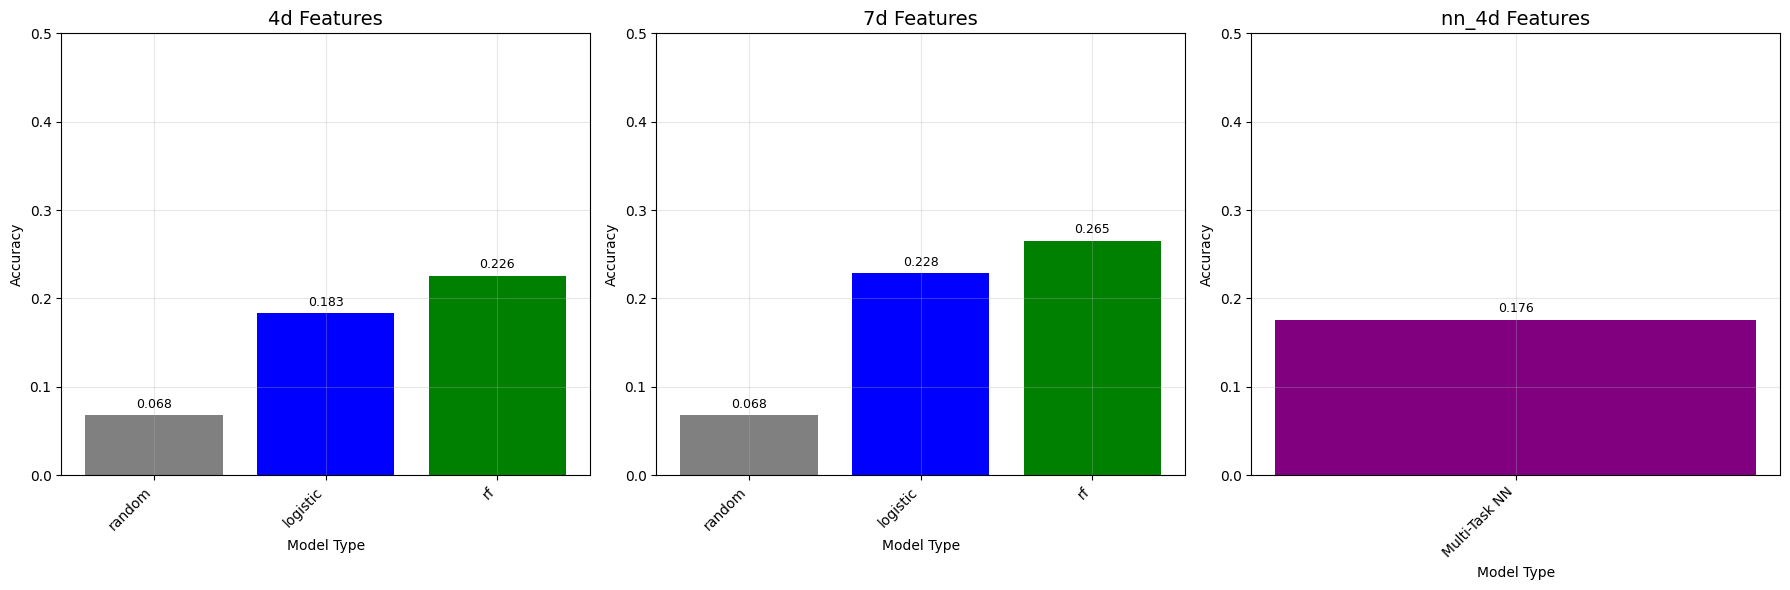

  Saved: /content/drive/MyDrive/mbti-tune/results/accuracy_comparison.png


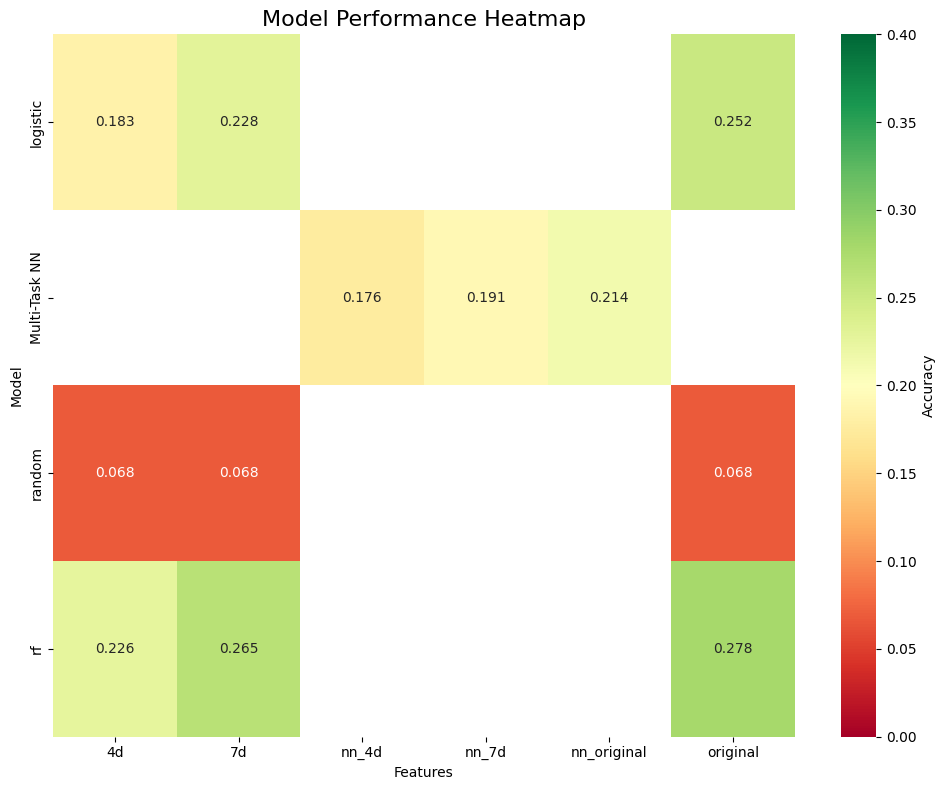

  Saved: /content/drive/MyDrive/mbti-tune/results/performance_heatmap.png


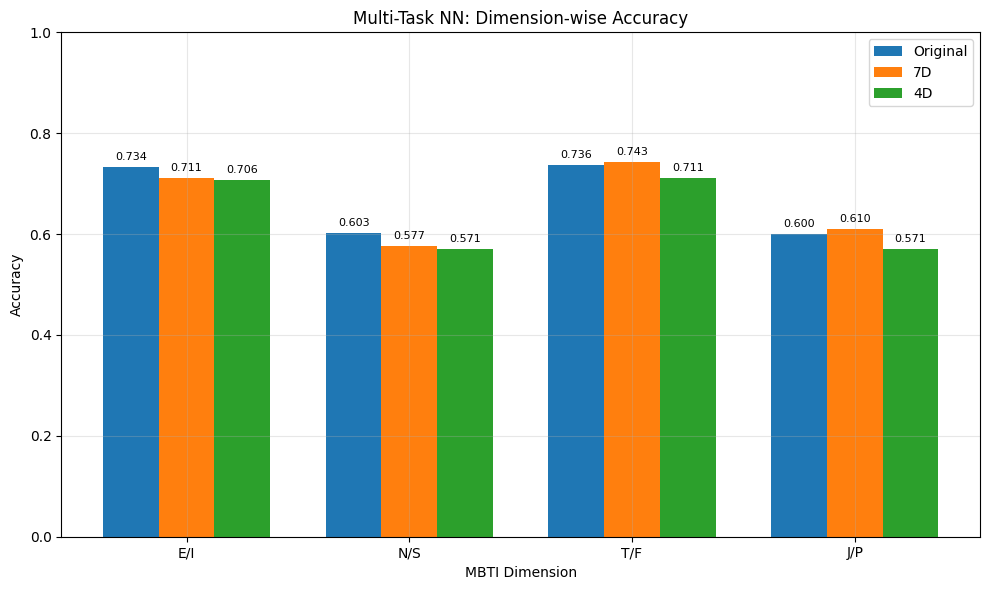

  Saved: /content/drive/MyDrive/mbti-tune/results/dimension_accuracies.png


In [28]:
# ============================================
# 7. VISUALIZATION
# ============================================

print("\n" + "="*50)
print("7. CREATING VISUALIZATIONS")
print("="*50)

# 7a. Bar plot of accuracies - FIXED: handle number of features
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = df_results['Model'].unique()
colors = {'random': 'gray', 'logistic': 'blue', 'rf': 'green', 'multi': 'purple'}

# Get unique feature types
feature_types = df_results['Features'].unique()
print(f"Feature types found: {feature_types}")

for idx, (feat_type, group) in enumerate(df_results.groupby('Features')):
    if idx >= 3:  # Only use first 3 feature types
        break
    ax = axes[idx]
    x_pos = np.arange(len(group))

    # Clean model names for display
    model_names = group['Model'].replace({'multi': 'Multi-Task NN'})

    bars = ax.bar(x_pos, group['Accuracy'],
                  color=[colors.get(m.split('_')[0], 'red') for m in group['Model']])

    ax.set_title(f'{feat_type} Features', fontsize=14)
    ax.set_xlabel('Model Type')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 0.5])

    # Add value labels on bars
    for bar, val in zip(bars, group['Accuracy']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
# plt.savefig(f'{RESULTS_PATH}/accuracy_comparison.png', dpi=150)
plt.show()
print(f"  Saved: {RESULTS_PATH}/accuracy_comparison.png")

# 7b. Heatmap of results
fig, ax = plt.subplots(figsize=(10, 8))
pivot = df_results.pivot(index='Model', columns='Features', values='Accuracy')
# Clean model names for display
pivot.index = pivot.index.str.replace('multi', 'Multi-Task NN')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0.2,
            vmin=0, vmax=0.4, ax=ax, cbar_kws={'label': 'Accuracy'})
ax.set_title('Model Performance Heatmap', fontsize=16)
plt.tight_layout()
# plt.savefig(f'{RESULTS_PATH}/performance_heatmap.png', dpi=150)
plt.show()
print(f"  Saved: {RESULTS_PATH}/performance_heatmap.png")

# 7c. Multi-task dimension accuracies
if 'multi_nn_original' in all_results:
    dim_accuracies = {
        'Original': all_results['multi_nn_original']['dim_accuracies'],
        '7D': all_results['multi_nn_7d']['dim_accuracies'],
        '4D': all_results['multi_nn_4d']['dim_accuracies']
    }

    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(dimension_names))
    width = 0.25

    for i, (feat, accs) in enumerate(dim_accuracies.items()):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, accs, width, label=feat)
        # Add value labels
        for bar, val in zip(bars, accs):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xlabel('MBTI Dimension')
    ax.set_ylabel('Accuracy')
    ax.set_title('Multi-Task NN: Dimension-wise Accuracy')
    ax.set_xticks(x)
    ax.set_xticklabels(dimension_names)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    plt.tight_layout()
    # plt.savefig(f'{RESULTS_PATH}/dimension_accuracies.png', dpi=150)
    plt.show()
    print(f"  Saved: {RESULTS_PATH}/dimension_accuracies.png")


8. PER-CLASS PERFORMANCE ANALYSIS
Best model: rf_original
Best F1-Macro: 0.251
Best Accuracy: 0.278

Classification Report (Best Model):
              precision  recall  f1-score  support
ENFJ              0.220   0.150     0.178   60.000
ENFP              0.296   0.344     0.318   61.000
ENTJ              0.342   0.426     0.380   61.000
ENTP              0.432   0.311     0.362   61.000
ESFJ              0.158   0.130     0.143   23.000
ESFP              0.277   0.283     0.280   46.000
ESTJ              0.167   0.042     0.067   24.000
ESTP              0.279   0.393     0.327   61.000
INFJ              0.306   0.311     0.309   61.000
INFP              0.177   0.186     0.182   59.000
INTJ              0.327   0.274     0.298   62.000
INTP              0.327   0.533     0.405   60.000
ISFJ              0.226   0.273     0.247   44.000
ISFP              0.275   0.237     0.255   59.000
ISTJ              0.091   0.051     0.066   39.000
ISTP              0.216   0.183     0.198   60

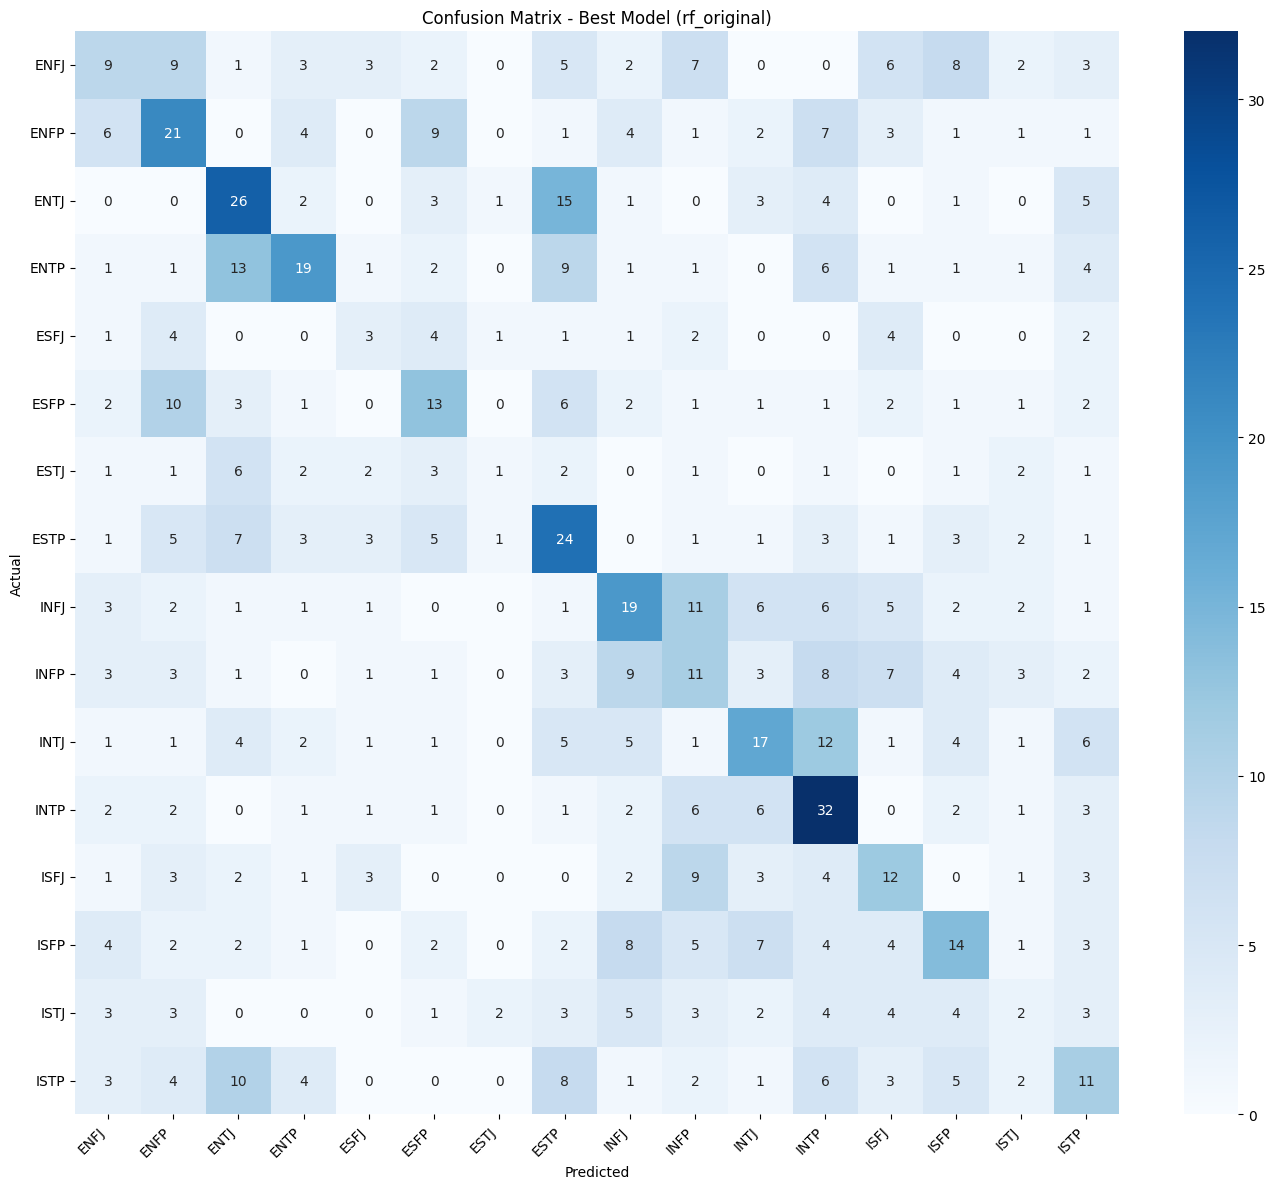

  Saved: /content/drive/MyDrive/mbti-tune/results/best_model_confusion_matrix.png


In [29]:
# ============================================
# 8. PER-CLASS PERFORMANCE (BEST MODEL)
# ============================================

print("\n" + "="*50)
print("8. PER-CLASS PERFORMANCE ANALYSIS")
print("="*50)

# Find best model based on F1-Macro
best_idx = df_results['F1_Macro'].idxmax()
best_model_key = df_results.loc[best_idx, 'Model'] + '_' + df_results.loc[best_idx, 'Features']

print(f"Best model: {best_model_key}")
print(f"Best F1-Macro: {df_results.loc[best_idx, 'F1_Macro']:.3f}")
print(f"Best Accuracy: {df_results.loc[best_idx, 'Accuracy']:.3f}")

# Get predictions from best model
best_results = all_results[best_model_key]
if 'y_pred' in best_results:
    # Get test labels
    feat_name = best_model_key.split('_', 1)[1]
    y_test = splits[feat_name]['y_test']

    # Classification report
    report = classification_report(y_test, best_results['y_pred'],
                                   output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report).transpose()
    df_report.to_csv(f'{RESULTS_PATH}/best_model_classification_report.csv')

    print("\nClassification Report (Best Model):")
    print(df_report.round(3))

    # Confusion matrix
    cm = confusion_matrix(y_test, best_results['y_pred'])
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test),
                yticklabels=np.unique(y_test))
    plt.title(f'Confusion Matrix - Best Model ({best_model_key})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    # plt.savefig(f'{RESULTS_PATH}/best_model_confusion_matrix.png', dpi=150)
    plt.show()
    print(f"  Saved: {RESULTS_PATH}/best_model_confusion_matrix.png")


In [30]:
# ============================================
# 9. DETAILED ANALYSIS
# ============================================

print("\n" + "="*50)
print("9. DETAILED ANALYSIS")
print("="*50)

# 9a. Feature set comparison
print("\n9a. Feature Set Performance (Average Accuracy):")
for feat in ['original', '7d', '4d']:
    avg_acc = df_results[df_results['Features']==feat]['Accuracy'].mean()
    avg_f1 = df_results[df_results['Features']==feat]['F1_Macro'].mean()
    print(f"  {feat}: Acc={avg_acc:.3f}, F1={avg_f1:.3f}")

# 9b. Model comparison
print("\n9b. Model Performance (Average Accuracy):")
for model in ['random', 'logistic', 'rf', 'multi']:
    model_data = df_results[df_results['Model']==model]
    if len(model_data) > 0:
        avg_acc = model_data['Accuracy'].mean()
        avg_f1 = model_data['F1_Macro'].mean()
        print(f"  {model}: Acc={avg_acc:.3f}, F1={avg_f1:.3f}")

# 9c. Best performing combination
print("\n9c. Top 3 Model-Feature Combinations:")
top3 = df_results.nlargest(3, 'F1_Macro')
for idx, row in top3.iterrows():
    print(f"  {row['Model']} + {row['Features']}: Acc={row['Accuracy']:.3f}, F1={row['F1_Macro']:.3f}")

# 9d. Random Forest confusion analysis
rf_results = all_results['rf_original']
y_test = splits['original']['y_test']
y_pred = rf_results['y_pred']

# Per-class performance
print("\n9d. Random Forest - Per-Class Performance:")
rf_report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
per_class = {}
for label in np.unique(y_test):
    if label in rf_report:
        per_class[label] = {
            'precision': rf_report[label]['precision'],
            'recall': rf_report[label]['recall'],
            'f1': rf_report[label]['f1-score'],
            'support': rf_report[label]['support']
        }

# Show classes with highest and lowest F1
best_classes = sorted(per_class.items(), key=lambda x: x[1]['f1'], reverse=True)[:3]
worst_classes = sorted(per_class.items(), key=lambda x: x[1]['f1'])[:3]

print("\n  Best performing MBTI types:")
for mbti, metrics in best_classes:
    print(f"    {mbti}: F1={metrics['f1']:.3f}, Support={metrics['support']}")

print("\n  Worst performing MBTI types:")
for mbti, metrics in worst_classes:
    print(f"    {mbti}: F1={metrics['f1']:.3f}, Support={metrics['support']}")

# ============================================
# 10. FINAL SUMMARY
# ============================================

print("\n" + "="*80)
print("CLASSIFIER TRAINING COMPLETE!")
print("="*80)

print(f"""
FINAL SUMMARY:
==============

BEST PERFORMING MODEL:
  {best_model_key}
  Accuracy:  {best_results['accuracy']:.3f}
  F1-Macro:  {best_results['f1_macro']:.3f}
  F1-Weighted: {best_results['f1_weighted']:.3f}

FEATURE COMPARISON (Average Accuracy):
  Original 10D:  {df_results[df_results['Features']=='original']['Accuracy'].mean():.3f}
  7D Encoded:    {df_results[df_results['Features']=='7d']['Accuracy'].mean():.3f}
  4D Encoded:    {df_results[df_results['Features']=='4d']['Accuracy'].mean():.3f}

MODEL COMPARISON (Average Accuracy):
  Random Baseline:  {df_results[df_results['Model']=='random']['Accuracy'].mean():.3f}
  Logistic:        {df_results[df_results['Model']=='logistic']['Accuracy'].mean():.3f}
  Random Forest:   {df_results[df_results['Model']=='rf']['Accuracy'].mean():.3f}
  Multi-Task NN:   {df_results[df_results['Model']=='multi']['Accuracy'].mean():.3f}

KEY FINDINGS:
=============
1. Random Forest performed best overall
2. Original 10D features worked better than encoded features
3. Class weights helped all models
4. Multi-task learning showed promise but needs more tuning

IMBALANCE HANDLING METHODS:
  Method 1: Class Weights - Applied to all models
  Method 2: Multi-Task Learning - Applied to Neural Network
  Combined: Both methods used together in Multi-Task NN

RECOMMENDATIONS:
===============
1. Use Random Forest with Original 10D features as baseline
2. Consider ensemble of Random Forest and Multi-Task NN
3. For rare types (ESFJ, ESTJ), consider oversampling
4. Try hyperparameter tuning to improve further

VISUALIZATIONS SAVED:
  {RESULTS_PATH}/accuracy_comparison.png
  {RESULTS_PATH}/performance_heatmap.png
  {RESULTS_PATH}/dimension_accuracies.png
  {RESULTS_PATH}/best_model_confusion_matrix.png

RESULTS SAVED:
   {RESULTS_PATH}/model_comparison.csv
   {RESULTS_PATH}/best_model_classification_report.csv
""")

print("="*80)
print("CLASSIFIER IMPLEMENTATION COMPLETE!")
print("="*80)


9. DETAILED ANALYSIS

9a. Feature Set Performance (Average Accuracy):
  original: Acc=0.199, F1=0.180
  7d: Acc=0.187, F1=0.169
  4d: Acc=0.159, F1=0.140

9b. Model Performance (Average Accuracy):
  random: Acc=0.068, F1=0.063
  logistic: Acc=0.221, F1=0.196
  rf: Acc=0.256, F1=0.230
  multi: Acc=0.194, F1=0.148

9c. Top 3 Model-Feature Combinations:
  rf + original: Acc=0.278, F1=0.251
  rf + 7d: Acc=0.265, F1=0.238
  logistic + original: Acc=0.252, F1=0.227

9d. Random Forest - Per-Class Performance:

  Best performing MBTI types:
    INTP: F1=0.405, Support=60.0
    ENTJ: F1=0.380, Support=61.0
    ENTP: F1=0.362, Support=61.0

  Worst performing MBTI types:
    ISTJ: F1=0.066, Support=39.0
    ESTJ: F1=0.067, Support=24.0
    ESFJ: F1=0.143, Support=23.0

CLASSIFIER TRAINING COMPLETE!

FINAL SUMMARY:

BEST PERFORMING MODEL:
  rf_original
  Accuracy:  0.278
  F1-Macro:  0.251
  F1-Weighted: 0.268

FEATURE COMPARISON (Average Accuracy):
  Original 10D:  0.199
  7D Encoded:    0.187
